# Prediction of car selling price
https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekhom

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import torch
import torch.nn as nn
import torch.optim as optim

import optuna

c:\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data loading

In [2]:
file_name = 'car_data.csv'

In [3]:
df  = pd.read_csv(file_name)
df.shape

(4340, 8)

In [4]:
df.isna().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [5]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [6]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## Feature preprocessing

In [7]:
df['age'] = max(df['year']) - df['year']
df.drop(['year',], axis=1, inplace=True)

In [8]:
scaler_km_driven = StandardScaler()
df['km_driven_sc'] = scaler_km_driven.fit_transform(df[['km_driven']])
df.drop(['km_driven',], axis=1, inplace=True)

In [9]:
df['fuel'].nunique()

5

In [10]:
df['fuel'].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [11]:
df = pd.get_dummies(df, columns=['fuel'], prefix='fuel', dtype=int)

In [12]:
df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [13]:
df = pd.get_dummies(df, columns=['seller_type'], prefix='seller', dtype=int)

In [14]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [15]:
df = pd.get_dummies(df, columns=['transmission'], prefix='transmission', dtype=int)

In [16]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Fourth & Above Owner',
       'Third Owner', 'Test Drive Car'], dtype=object)

In [17]:
mapping = {'Test Drive Car': 0, 
           'First Owner': 1,
           'Second Owner': 2,
           'Third Owner': 3,
           'Fourth & Above Owner': 4}
df['owner_code'] = df['owner'].map(mapping)
df.drop(['owner'], axis=1, inplace=True)

In [18]:
df['manufacter'] = df['name'].str.split().str[0]

In [19]:
df['manufacter'].nunique()

29

In [20]:
df = pd.get_dummies(df, columns=['manufacter'], prefix='manufacter', dtype=int)
df.drop(['name'], axis=1, inplace=True)

## EDA

In [21]:
num_cols = ['selling_price', 'age', 'km_driven_sc']
cat_cols = set(df.columns)
for col_name in num_cols:
    cat_cols.remove(col_name)
print('Numeric columns:')
print(num_cols)
print('Categorical columns:')
print(cat_cols)

Numeric columns:
['selling_price', 'age', 'km_driven_sc']
Categorical columns:
{'manufacter_Mitsubishi', 'manufacter_Mercedes-Benz', 'manufacter_Jeep', 'manufacter_Maruti', 'seller_Individual', 'manufacter_Mahindra', 'manufacter_BMW', 'manufacter_OpelCorsa', 'manufacter_Tata', 'seller_Dealer', 'manufacter_Jaguar', 'manufacter_Datsun', 'manufacter_Volkswagen', 'seller_Trustmark Dealer', 'fuel_Petrol', 'fuel_Electric', 'manufacter_Chevrolet', 'manufacter_Toyota', 'transmission_Manual', 'manufacter_Kia', 'manufacter_Force', 'manufacter_Land', 'fuel_LPG', 'manufacter_Daewoo', 'manufacter_Isuzu', 'manufacter_Nissan', 'manufacter_Audi', 'manufacter_Skoda', 'manufacter_Renault', 'transmission_Automatic', 'manufacter_Volvo', 'manufacter_Honda', 'manufacter_MG', 'fuel_CNG', 'manufacter_Ford', 'manufacter_Hyundai', 'manufacter_Ambassador', 'manufacter_Fiat', 'owner_code', 'fuel_Diesel'}


### Goal target `selling_price`

Skewness: 4.892021472306356
Kurtosis: 37.08754263212727


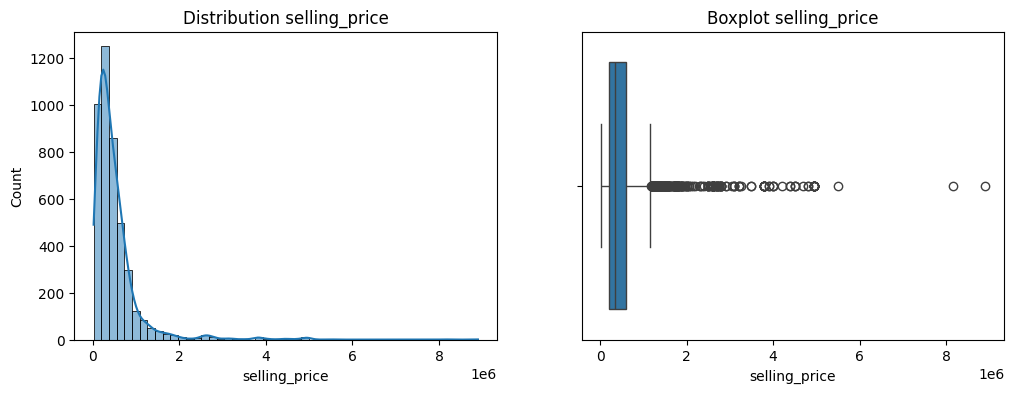

In [22]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['selling_price'], kde=True, bins=50)
plt.title('Distribution selling_price')

plt.subplot(1,2,2)
sns.boxplot(x=df['selling_price'])
plt.title('Boxplot selling_price')

print('Skewness:', df['selling_price'].skew())
print('Kurtosis:', df['selling_price'].kurtosis())

Skewness after log: 0.06017265586710223


<Axes: xlabel='selling_price_log', ylabel='Count'>

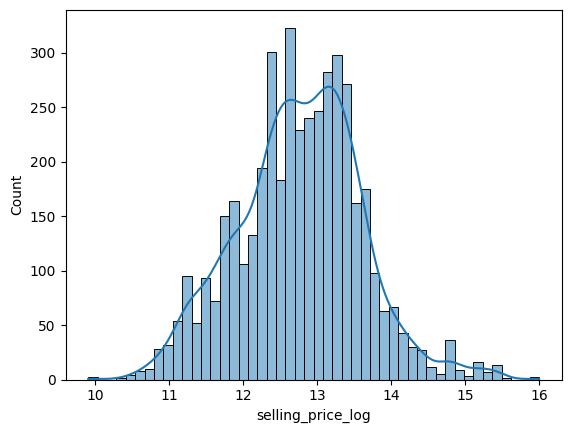

In [23]:
df['selling_price_log'] = np.log1p(df['selling_price'])
print('Skewness after log:', df['selling_price_log'].skew())
sns.histplot(df['selling_price_log'], kde=True)

In [24]:
df.drop(['selling_price'], axis=1, inplace=True)

### Numeric features

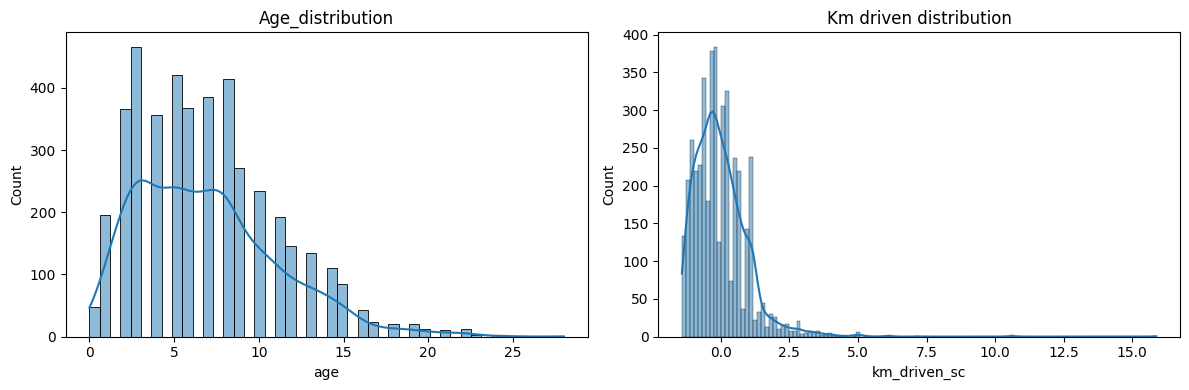

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'], kde=True, ax=axes[0])
axes[0].set_title('Age_distribution')
sns.histplot(df['km_driven_sc'], kde=True, ax=axes[1])   
axes[1].set_title('Km driven distribution')
plt.tight_layout()

Text(0.5, 1.0, 'Correlation Matrix of Numerical Features')

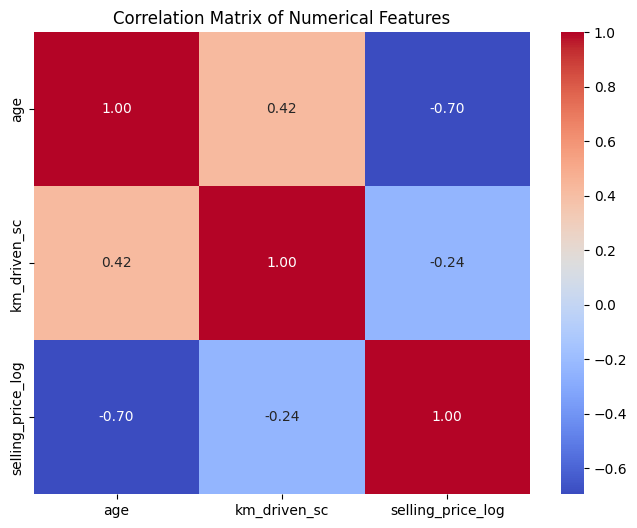

In [26]:
num_cols.remove('selling_price')
num_cols.append('selling_price_log')

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')

### Categorical features

In [27]:
ohe_prefixes = ['fuel', 'manufacter', 'transmission', 'seller']
original_cats = {}
df_eda = df.copy()
for prefix in ohe_prefixes:
    cols = [c for c in df.columns if c.startswith(prefix + '_')]
    if not cols:
        continue
    original_cats[prefix] = df[cols].idxmax(axis=1).str.replace(prefix + '_', '')
for col_name, series in original_cats.items():
    df_eda[col_name] = series

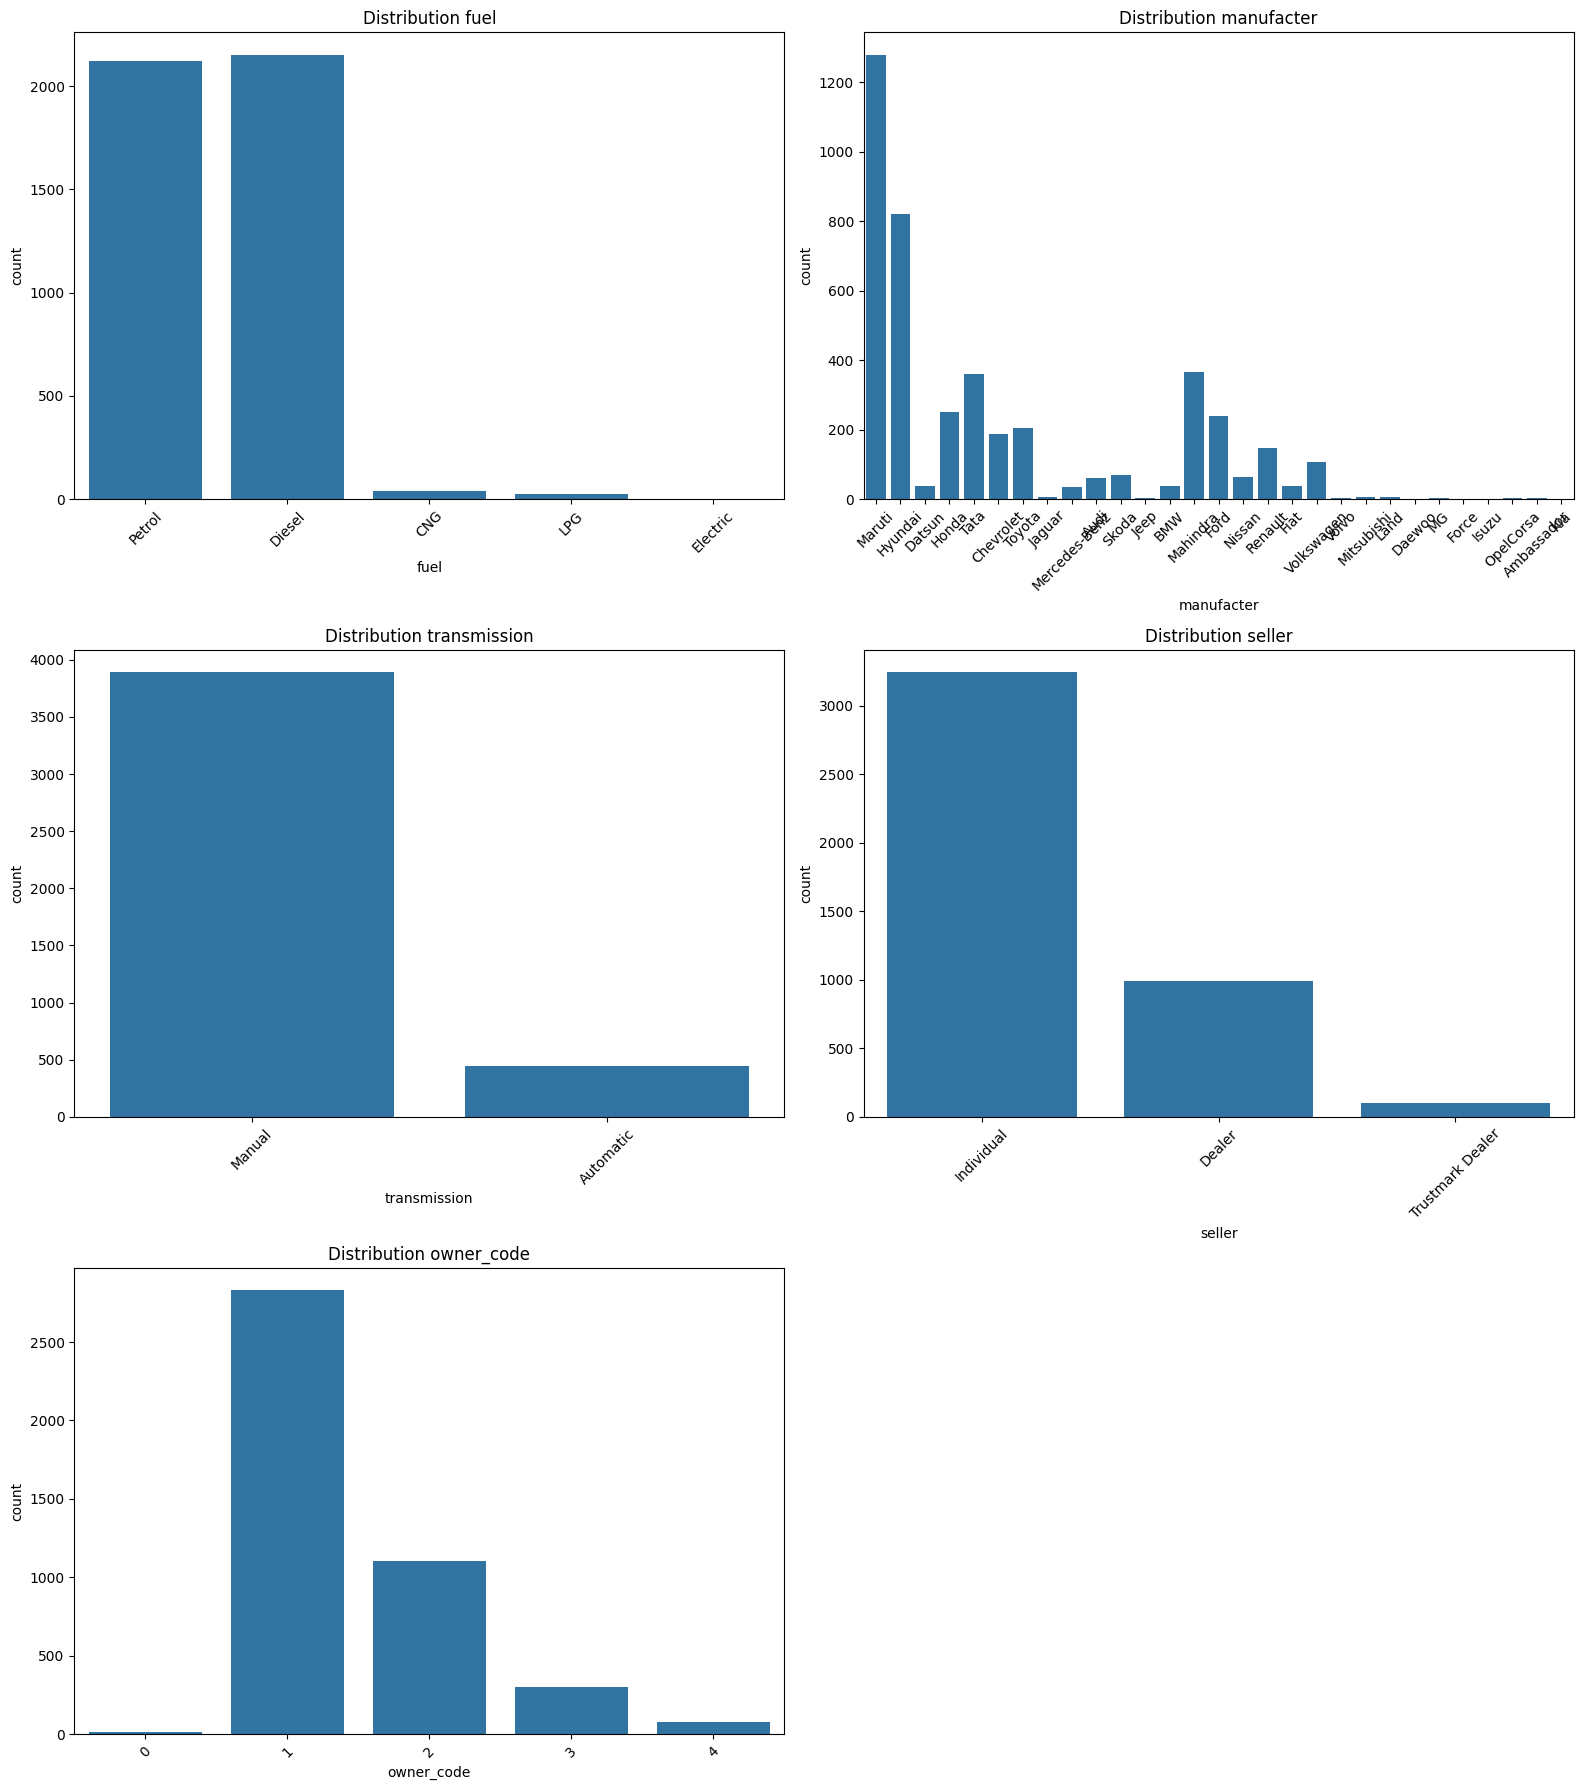

In [28]:
cat_features = ['fuel', 'manufacter', 'transmission', 'seller', 'owner_code']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    if feat == 'manufacturer':
        top_manufacturers = df_eda[feat].value_counts().nlargest(15).index
        plot_data = df_eda[df_eda[feat].isin(top_manufacturers)]
        order = top_manufacturers
        sns.countplot(y=feat, data=plot_data, order=order, ax=axes[i])
        axes[i].set_title('Top-15 manufacturers')
    else:
        order = None
        if feat == 'owner_code':
            order = sorted(df_eda[feat].unique())
        sns.countplot(x=feat, data=df_eda, order=order, ax=axes[i])
        axes[i].set_title(f'Distribution {feat}')
    axes[i].tick_params(axis='x', rotation=45)

if len(cat_features) < len(axes):
    axes[-1].set_visible(False)
plt.tight_layout()

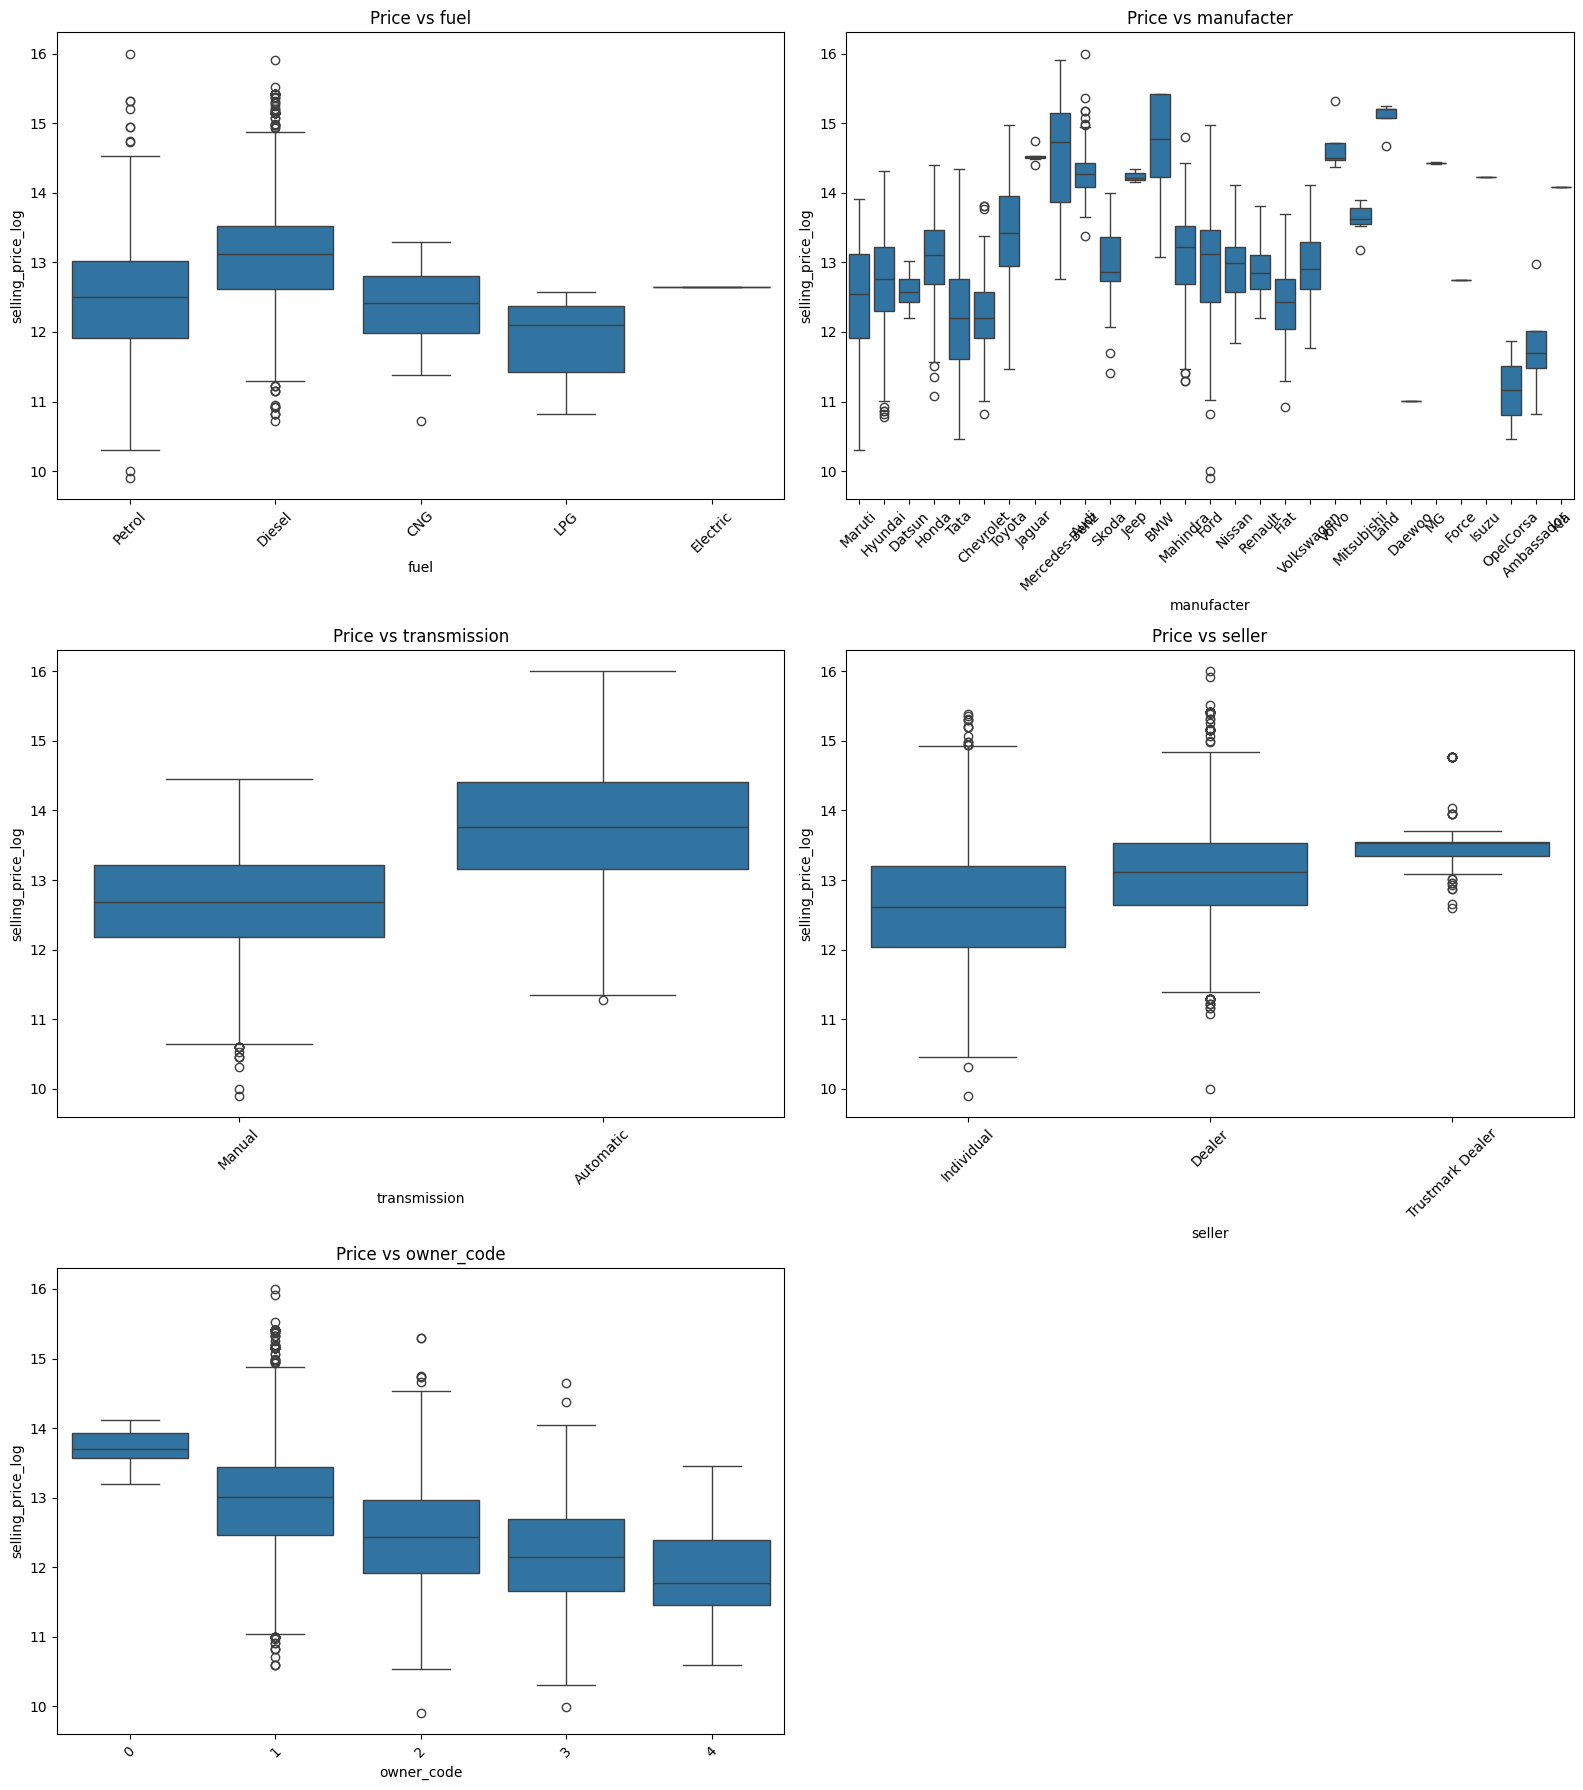

In [29]:
target = 'selling_price_log'

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    if feat == 'manufacturer':
        top_med = df_eda.groupby(feat)[target].median().nlargest(15).index
        plot_data = df_eda[df_eda[feat].isin(top_med)]
        order = top_med
        sns.boxplot(y=feat, x=target, data=plot_data, order=order, ax=axes[i])
        axes[i].set_title('Price of top-15 manufacturers')
    else:
        order = None
        if feat == 'owner_code':
            order = sorted(df_eda[feat].unique())
        sns.boxplot(x=feat, y=target, data=df_eda, order=order, ax=axes[i])
        axes[i].set_title(f'Price vs {feat}')
    axes[i].tick_params(axis='x', rotation=45)

if len(cat_features) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()

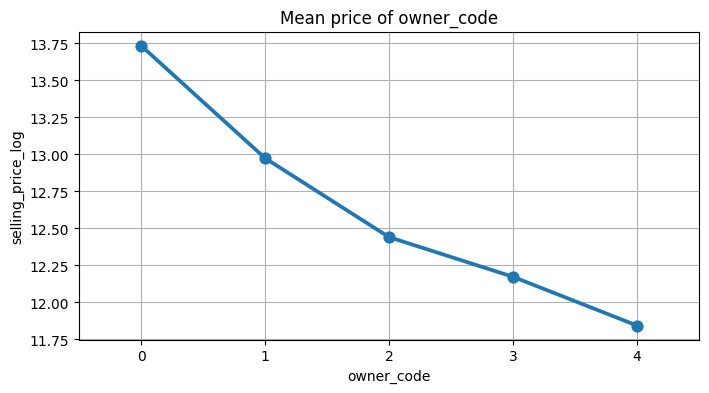

In [30]:
mean_price_by_owner = df_eda.groupby('owner_code')[target].mean().reset_index()
plt.figure(figsize=(8,4))
sns.pointplot(x='owner_code', y=target, data=mean_price_by_owner, marker='o')
plt.title('Mean price of owner_code')
plt.grid()
plt.show()

## Regression baselines

In [31]:
y = df['selling_price_log']
X = df.drop(['selling_price_log'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3472, 42), (3472,), (868, 42), (868,))

### Dummy

In [32]:
dummy_model = DummyRegressor()

def rmse_expm1(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true, y_pred))

def r2_expm1(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return r2_score(y_true, y_pred)

rmse_scorer = make_scorer(rmse_expm1, greater_is_better=False)
r2_scorer   = make_scorer(r2_expm1, greater_is_better=True)

def try_baseline_model(model):
    cv_results = cross_validate(
        model, X_train, y_train, cv=5,
        scoring={'RMSE_orig': rmse_scorer, 'R2_orig': r2_scorer}
    )

    cv_rmse_orig = -cv_results['test_RMSE_orig'].mean()
    cv_r2_orig   = cv_results['test_R2_orig'].mean()
    print(f'Train RMSE: {cv_rmse_orig:.0f}  | Train R2: {cv_r2_orig:.2f}')

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)

    test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    test_r2   = r2_score(y_test_orig, y_pred_orig)
    print(f'Test RMSE: {test_rmse:.0f} | Test R2: {test_r2:.2f}')
    
try_baseline_model(dummy_model)

Train RMSE: 574140  | Train R2: -0.07
Test RMSE: 676360 | Test R2: -0.09


### Linear

In [33]:
linear_model = LinearRegression()
try_baseline_model(linear_model)

Train RMSE: 270058  | Train R2: 0.76
Test RMSE: 295273 | Test R2: 0.79


### Ridge

In [34]:
def grid_baseline_model(model, grid):
    grid = GridSearchCV(
        model,
        param_grid,
        cv=5,
        scoring={'RMSE': rmse_scorer, 'R2': r2_scorer},
        refit='RMSE',
        return_train_score=False,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print(f'Best params: {grid.best_params_}')
    return grid.best_params_
    
ridge_model = Ridge()
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

best_params = grid_baseline_model(ridge_model, param_grid)
ridge_model = Ridge(**best_params)
try_baseline_model(ridge_model)

Best params: {'alpha': 0.1}
Train RMSE: 269348  | Train R2: 0.76
Test RMSE: 292352 | Test R2: 0.80


### Lasso

In [35]:
lasso_model = Lasso()
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'max_iter': [5000] 
}

best_params = grid_baseline_model(lasso_model, param_grid)
lasso_model = Lasso(**best_params)
try_baseline_model(lasso_model)

Best params: {'alpha': 0.0001, 'max_iter': 5000}
Train RMSE: 270508  | Train R2: 0.76
Test RMSE: 287321 | Test R2: 0.80


### Elastic net

In [36]:
elnet_model = ElasticNet()
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'max_iter': [5000] 
}

best_params = grid_baseline_model(elnet_model, param_grid)
elnet_model = ElasticNet(**best_params)
try_baseline_model(elnet_model)

Best params: {'alpha': 0.0001, 'l1_ratio': 0.1, 'max_iter': 5000}
Train RMSE: 268977  | Train R2: 0.76
Test RMSE: 286701 | Test R2: 0.80


### SVM

In [37]:
svr_model = SVR()
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

best_params = grid_baseline_model(svr_model, param_grid)
svr_model = SVR(**best_params)
try_baseline_model(svr_model)

Best params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Train RMSE: 259677  | Train R2: 0.78
Test RMSE: 230401 | Test R2: 0.87


### Random forest

In [38]:
rf_model = RandomForestRegressor()
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [2, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

best_params = grid_baseline_model(rf_model, param_grid)
rf_model = RandomForestRegressor(**best_params)
try_baseline_model(rf_model)

Best params: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Train RMSE: 260581  | Train R2: 0.78
Test RMSE: 281381 | Test R2: 0.81


### Gradient boosting

In [39]:
gb_model = GradientBoostingRegressor()
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

best_params = grid_baseline_model(gb_model, param_grid)
gb_model = GradientBoostingRegressor(**best_params)
try_baseline_model(gb_model)

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 1.0}
Train RMSE: 238692  | Train R2: 0.82
Test RMSE: 265178 | Test R2: 0.83


### XGBoost

In [40]:
xg_model = XGBRegressor()
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

best_params = grid_baseline_model(xg_model, param_grid)
xg_model = XGBRegressor(**best_params)
try_baseline_model(xg_model)

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}
Train RMSE: 235530  | Train R2: 0.82
Test RMSE: 279553 | Test R2: 0.81


### Dense NN

In [41]:
X_train_np = X_train.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1)
X_test_np  = X_test.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32).reshape(-1, 1)

X_train_t = torch.tensor(X_train_np)
y_train_t = torch.tensor(y_train_np)
X_test_t  = torch.tensor(X_test_np)
y_test_t  = torch.tensor(y_test_np)

In [42]:
class RegressionNet(nn.Module):
    def __init__(self, input_dim, hidden_dims = [128, 64], dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [43]:
input_dim = X_train.shape[1]
model = RegressionNet(input_dim)
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.train()

epochs = 200
batch_size = 128
dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    epoch_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, loss: {epoch_loss/len(dataset):.4f}")        

Epoch 20/200, loss: 1.0321
Epoch 40/200, loss: 0.8475
Epoch 60/200, loss: 0.8422
Epoch 80/200, loss: 0.7834
Epoch 100/200, loss: 0.7723
Epoch 120/200, loss: 0.7262
Epoch 140/200, loss: 0.7065
Epoch 160/200, loss: 0.6622
Epoch 180/200, loss: 0.6344
Epoch 200/200, loss: 0.6457


In [44]:
model.eval()
with torch.no_grad():
    y_pred_train_log = model(X_train_t).numpy()
    y_pred_test_log  = model(X_test_t).numpy()

y_train_nonlog = np.expm1(y_train_np)
y_pred_train_nonlog = np.expm1(y_pred_train_log)
y_test_nonlog  = np.expm1(y_test_np)
y_pred_test_nonlog  = np.expm1(y_pred_test_log)

train_rmse = np.sqrt(mean_squared_error(y_train_nonlog, y_pred_train_nonlog))
test_rmse  = np.sqrt(mean_squared_error(y_test_nonlog, y_pred_test_nonlog))
train_r2 = r2_score(y_train_nonlog, y_pred_train_nonlog)
test_r2  = r2_score(y_test_nonlog, y_pred_test_nonlog)

print(f'Train RMSE: {train_rmse:.0f}  | Train R2: {train_r2:.2f}')
print(f'Test RMSE: {test_rmse:.0f}  | Test R2: {test_r2:.2f}')

Train RMSE: 264538  | Train R2: 0.78
Test RMSE: 317659  | Test R2: 0.76


In [45]:
model = RegressionNet(input_dim, hidden_dims=[256, 128, 64])
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, loss: {epoch_loss/len(dataset):.4f}")      

Epoch 20/200, loss: 1.0711
Epoch 40/200, loss: 0.8414
Epoch 60/200, loss: 0.7223
Epoch 80/200, loss: 0.6912
Epoch 100/200, loss: 0.6649
Epoch 120/200, loss: 0.6241
Epoch 140/200, loss: 0.5852
Epoch 160/200, loss: 0.5903
Epoch 180/200, loss: 0.5662
Epoch 200/200, loss: 0.5918


In [46]:
model.eval()
with torch.no_grad():
    y_pred_train_log = model(X_train_t).numpy()
    y_pred_test_log  = model(X_test_t).numpy()

y_train_nonlog = np.expm1(y_train_np)
y_pred_train_nonlog = np.expm1(y_pred_train_log)
y_test_nonlog  = np.expm1(y_test_np)
y_pred_test_nonlog  = np.expm1(y_pred_test_log)

train_rmse = np.sqrt(mean_squared_error(y_train_nonlog, y_pred_train_nonlog))
test_rmse  = np.sqrt(mean_squared_error(y_test_nonlog, y_pred_test_nonlog))
train_r2 = r2_score(y_train_nonlog, y_pred_train_nonlog)
test_r2  = r2_score(y_test_nonlog, y_pred_test_nonlog)

print(f'Train RMSE: {train_rmse:.0f}  | Train R2: {train_r2:.2f}')
print(f'Test RMSE: {test_rmse:.0f}  | Test R2: {test_r2:.2f}')

Train RMSE: 260889  | Train R2: 0.78
Test RMSE: 320258  | Test R2: 0.76


### Baseline results

| Column 1 | train RMSE |  train r2 | test RMSE | test R2  
|----------|----------|----------|----------|----------|
| Dummy    | 592658     | 0.07   | 622248 | 0.07 |
| Linear    | 277280     | 0.76   | 278080  | 0.79 |
| Ridge    | 273082     | 0.77   | 270561  | 0.80 |
| Lasso    | 275391         | 0.77   | 274337    | 0.79 |
| Elastic net    | 274331   | 0.77   | 273596    | 0.79 |
| SVR    | 247664        | 0.81   | 275791  |  0.79 |
| Random forest    | 260651          | 0.79   | 264498   |  0.81 |
| Gradient boosting    | 246722            | 0.81   | 253842     |  0.82 |
| XGBoost    | 244309  | 0.81   | 232371      |  0.85 |
| Dense NN 2    | 230525      | 0.84   | 270359        |  0.80 |
| Dense NN 3    | 313771   | 0.70   | 365008          |  0.63 |

## Tuning of XGBoost

### On full data

In [47]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }
    model = XGBRegressor(**params, verbosity=0)
    
    scores = cross_val_score(model, X_train, y_train, 
                             cv=5, scoring=rmse_scorer, n_jobs=-1)
    rmse_cv = -scores.mean()   
    return rmse_cv

In [48]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)
print('Best params', study.best_params)
print(f'Best CV RMSE: {study.best_value:,.0f}')

[I 2026-06-15 16:35:26,119] A new study created in memory with name: no-name-eb237b2f-32a2-427c-bd5d-c87c3bca5b4e
Best trial: 0. Best value: 250251:   2%|▏         | 1/50 [00:00<00:31,  1.54it/s]

[I 2026-06-15 16:35:26,770] Trial 0 finished with value: 250251.4757972403 and parameters: {'n_estimators': 174, 'max_depth': 6, 'learning_rate': 0.17062414836365597, 'subsample': 0.7772200669437581, 'colsample_bytree': 0.7034614234931013, 'min_child_weight': 2, 'reg_alpha': 0.0004223707888364391, 'reg_lambda': 1.7984106983091742e-07}. Best is trial 0 with value: 250251.4757972403.


Best trial: 0. Best value: 250251:   4%|▍         | 2/50 [00:01<00:50,  1.05s/it]

[I 2026-06-15 16:35:28,104] Trial 1 finished with value: 257239.89429476377 and parameters: {'n_estimators': 384, 'max_depth': 9, 'learning_rate': 0.12316516055399719, 'subsample': 0.9160276062557567, 'colsample_bytree': 0.9498991351785867, 'min_child_weight': 1, 'reg_alpha': 3.2871775469199834e-06, 'reg_lambda': 1.930850205382301e-07}. Best is trial 0 with value: 250251.4757972403.


Best trial: 0. Best value: 250251:   6%|▌         | 3/50 [00:02<00:45,  1.03it/s]

...

[I 2026-06-15 16:35:43,302] Trial 47 finished with value: 295876.39333008474 and parameters: {'n_estimators': 434, 'max_depth': 3, 'learning_rate': 0.06319958823579269, 'subsample': 0.9078936713747925, 'colsample_bytree': 0.8643994156442449, 'min_child_weight': 6, 'reg_alpha': 0.0001773511146885929, 'reg_lambda': 0.004812016713991883}. Best is trial 29 with value: 237859.61948281186.


Best trial: 29. Best value: 237860:  98%|█████████▊| 49/50 [00:17<00:00,  3.52it/s]

[I 2026-06-15 16:35:43,582] Trial 48 finished with value: 252623.46907658316 and parameters: {'n_estimators': 375, 'max_depth': 4, 'learning_rate': 0.035105509768028544, 'subsample': 0.9325650050887743, 'colsample_bytree': 0.8531265644876413, 'min_child_weight': 1, 'reg_alpha': 0.004498066072398904, 'reg_lambda': 0.2628670743945336}. Best is trial 29 with value: 237859.61948281186.


Best trial: 29. Best value: 237860: 100%|██████████| 50/50 [00:17<00:00,  2.81it/s]

[I 2026-06-15 16:35:43,895] Trial 49 finished with value: 251145.00746101132 and parameters: {'n_estimators': 466, 'max_depth': 4, 'learning_rate': 0.06316431430355302, 'subsample': 0.967973709459697, 'colsample_bytree': 0.889754670305885, 'min_child_weight': 1, 'reg_alpha': 0.0015511539295430708, 'reg_lambda': 0.00037812291185242093}. Best is trial 29 with value: 237859.61948281186.
Best params {'n_estimators': 270, 'max_depth': 7, 'learning_rate': 0.1303333580806354, 'subsample': 0.8933354142531001, 'colsample_bytree': 0.9455033752575165, 'min_child_weight': 1, 'reg_alpha': 0.04108618251772681, 'reg_lambda': 0.7712924792657594}
Best CV RMSE: 237,860


In [49]:
best_xgb = XGBRegressor(**study.best_params, verbosity=0, random_state=42)
try_baseline_model(best_xgb)

Train RMSE: 237860  | Train R2: 0.82
Test RMSE: 283908 | Test R2: 0.81


### Without outliers

In [50]:
numeric_features = ['age', 'km_driven_sc']
def iqr_outlier_mask(df, cols, factor=1.5):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        mask &= (df[col] >= lower) & (df[col] <= upper)
    return mask

In [51]:
train_mask = iqr_outlier_mask(X_train, numeric_features, factor=1.5)
X_train_clean = X_train[train_mask]
y_train_clean = y_train[train_mask]

In [52]:
best_xgb = XGBRegressor(**study.best_params, verbosity=0, random_state=42)
try_baseline_model(best_xgb)

Train RMSE: 237860  | Train R2: 0.82
Test RMSE: 283908 | Test R2: 0.81


### Feature importance

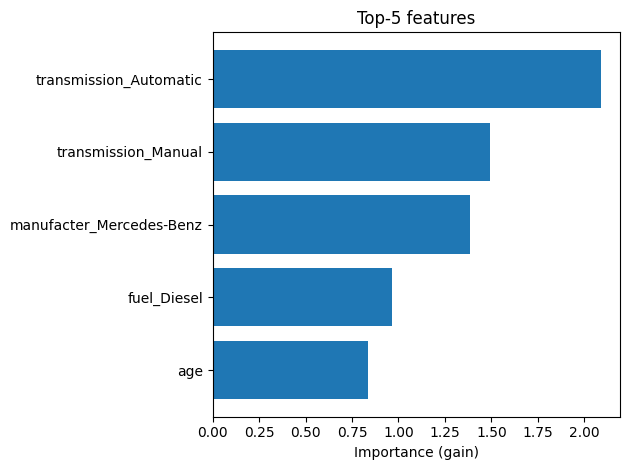

In [53]:
importance = best_xgb.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values('importance', ascending=False)

plt.figure()
plt.barh(importance_df['feature'].head(5), importance_df['importance'].head(5))
plt.gca().invert_yaxis()
plt.xlabel('Importance (gain)')
plt.title('Top-5 features')
plt.tight_layout()